# Stack Overflow Question Activity: Macroscopic Time-Series Analysis

## Goal
Characterize the long-run evolution of new Stack Overflow questions without imposing an explanatory mechanism.

## Context & Methods
The primary source is `new-questions-per-day-by-sites-since-2008.csv`. The `StackOverflowQuestions` column is aggregated to weekly, monthly, and yearly frequencies. Trend, seasonality, year-over-year growth, peak drawdown, and rolling slopes are examined.

In [1]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

def locate_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "database").exists() and (candidate / "notebooks").exists():
            return candidate
        nested = candidate / "stack_exchange_analysis"
        if (nested / "database").exists() and (nested / "notebooks").exists():
            return nested
    raise FileNotFoundError("Could not locate stack_exchange_analysis project root.")

PROJECT_ROOT = locate_project_root()
DATA_DIR = PROJECT_ROOT / "database"
ANALYSIS_DIR = PROJECT_ROOT / "analysis"
ANALYSIS_DIR.mkdir(exist_ok=True)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from analysis_utils import read_csv_flexible, parse_best_date_column, drop_incomplete_last_period, save_figure

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\Osvaldo\OneDrive\github_oz\stack_analysis\stack_exchange_analysis


### 1. Load and validate the daily series

In [2]:
path = DATA_DIR / "new-questions-per-day-by-sites-since-2008.csv"
df = read_csv_flexible(path)
required = {"Day", "StackOverflowQuestions"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

df["Day"] = pd.to_datetime(df["Day"], errors="coerce")
df["StackOverflowQuestions"] = pd.to_numeric(df["StackOverflowQuestions"], errors="coerce")
df = df.dropna(subset=["Day", "StackOverflowQuestions"]).sort_values("Day")
df = df.drop_duplicates(subset="Day", keep="last")
print(df[["Day", "StackOverflowQuestions"]].agg({"Day":["min","max"], "StackOverflowQuestions":["min","max","mean"]}))

            Day  StackOverflowQuestions
min  2008-07-31                4.000000
max  2026-05-16             8511.000000
mean        NaT             3715.543468


### 2. Daily activity and moving averages

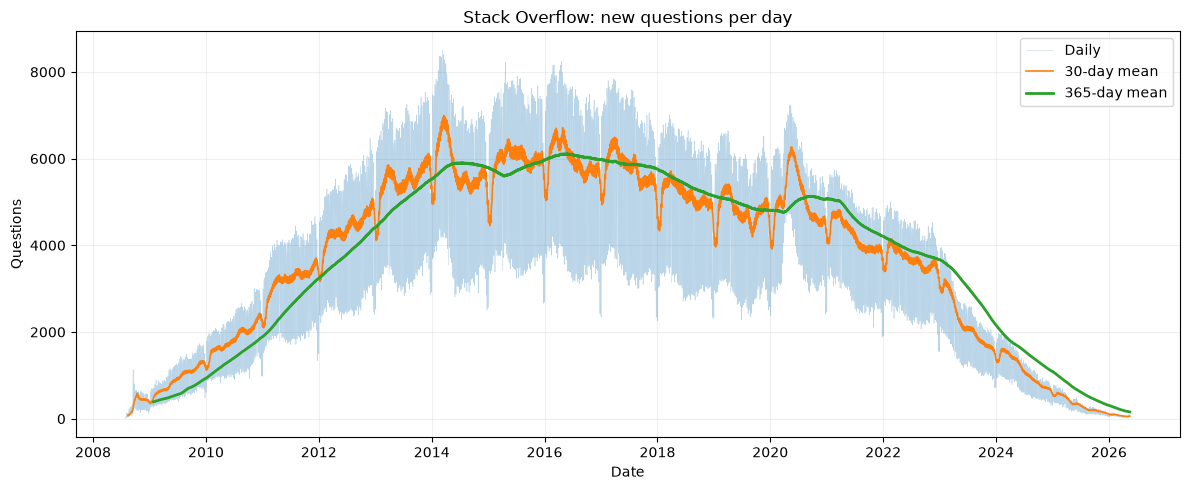

In [3]:
ts = df.set_index("Day")["StackOverflowQuestions"].asfreq("D")
# Missing calendar days are retained as NaN rather than silently converted to zero.
ma7 = ts.rolling(7, min_periods=4).mean()
ma30 = ts.rolling(30, min_periods=15).mean()
ma365 = ts.rolling(365, min_periods=180).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ts.index, ts, linewidth=0.4, alpha=0.30, label="Daily")
ax.plot(ma30.index, ma30, linewidth=1.2, label="30-day mean")
ax.plot(ma365.index, ma365, linewidth=2.0, label="365-day mean")
ax.set(title="Stack Overflow: new questions per day", xlabel="Date", ylabel="Questions")
ax.legend()
ax.grid(alpha=0.2)
save_figure(fig, ANALYSIS_DIR / "questions_daily_trend.png")
plt.show()

### 3. Monthly and annual totals

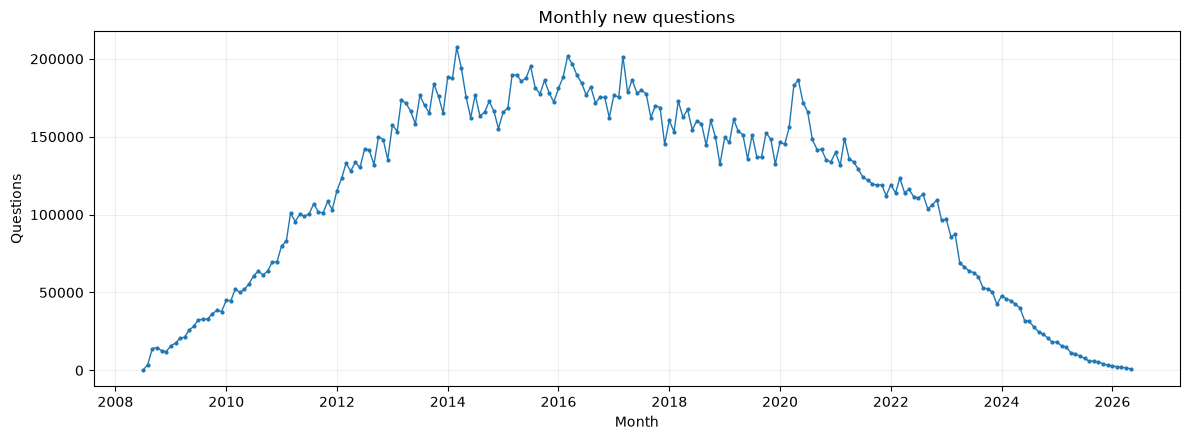

,questions,yoy_pct
Day,,
2008-01-01,57144,NaN
2009-01-01,340245,495.416842
2010-01-01,688445,102.338021
2011-01-01,1180190,71.428364
2012-01-01,1612317,36.615037
2013-01-01,2017284,25.117083
2014-01-01,2115586,4.872988
2015-01-01,2177330,2.918529
2016-01-01,2185292,0.365677


In [4]:
monthly = ts.resample("MS").sum(min_count=1)
monthly = drop_incomplete_last_period(monthly, freq="M")
yearly = ts.resample("YS").sum(min_count=1)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly.index, monthly, marker="o", markersize=2, linewidth=1)
ax.set(title="Monthly new questions", xlabel="Month", ylabel="Questions")
ax.grid(alpha=0.2)
save_figure(fig, ANALYSIS_DIR / "questions_monthly.png")
plt.show()

annual_table = yearly.rename("questions").to_frame()
annual_table["yoy_pct"] = annual_table["questions"].pct_change() * 100
annual_table

### 4. Peak drawdown

Peak month: 2014-03; questions=207,298
Latest complete month: 2026-05; questions=976
Drawdown from historical monthly peak: 99.5%


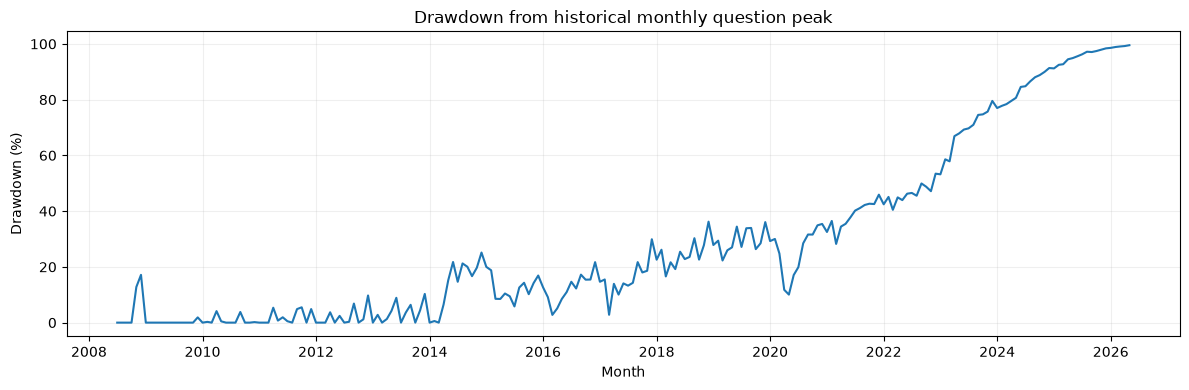

In [5]:
rolling_peak = monthly.cummax()
drawdown = 1 - monthly / rolling_peak
peak_month = monthly.idxmax()
peak_value = monthly.max()
latest_month = monthly.dropna().index.max()
latest_value = monthly.loc[latest_month]
print(f"Peak month: {peak_month:%Y-%m}; questions={peak_value:,.0f}")
print(f"Latest complete month: {latest_month:%Y-%m}; questions={latest_value:,.0f}")
print(f"Drawdown from historical monthly peak: {drawdown.loc[latest_month]:.1%}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(drawdown.index, drawdown * 100)
ax.set(title="Drawdown from historical monthly question peak", xlabel="Month", ylabel="Drawdown (%)")
ax.grid(alpha=0.2)
save_figure(fig, ANALYSIS_DIR / "questions_drawdown.png")
plt.show()

### 5. Year-over-year growth

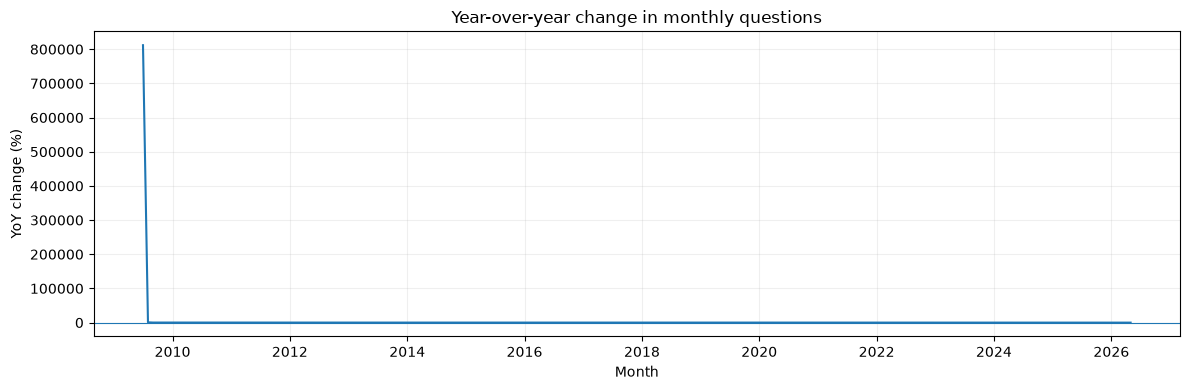

In [6]:
yoy = monthly.pct_change(12) * 100
fig, ax = plt.subplots(figsize=(12, 4))
ax.axhline(0, linewidth=0.8)
ax.plot(yoy.index, yoy)
ax.set(title="Year-over-year change in monthly questions", xlabel="Month", ylabel="YoY change (%)")
ax.grid(alpha=0.2)
save_figure(fig, ANALYSIS_DIR / "questions_yoy.png")
plt.show()

### 6. Calendar effects

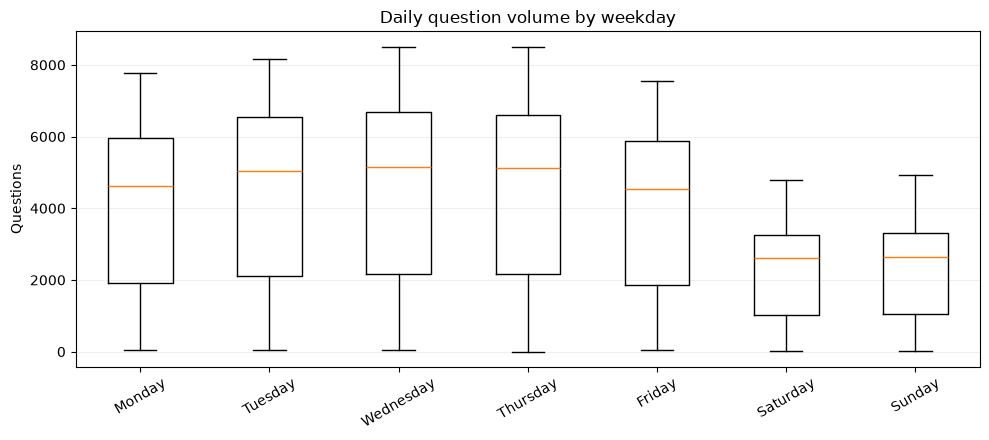

In [7]:
calendar = df[["Day", "StackOverflowQuestions"]].copy()
calendar["weekday"] = calendar["Day"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
data = [calendar.loc[calendar["weekday"] == d, "StackOverflowQuestions"].dropna().values for d in order]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.boxplot(data, tick_labels=order, showfliers=False)
ax.set(title="Daily question volume by weekday", ylabel="Questions")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.2)
save_figure(fig, ANALYSIS_DIR / "questions_weekday.png")
plt.show()

### 7. Seasonal-trend decomposition

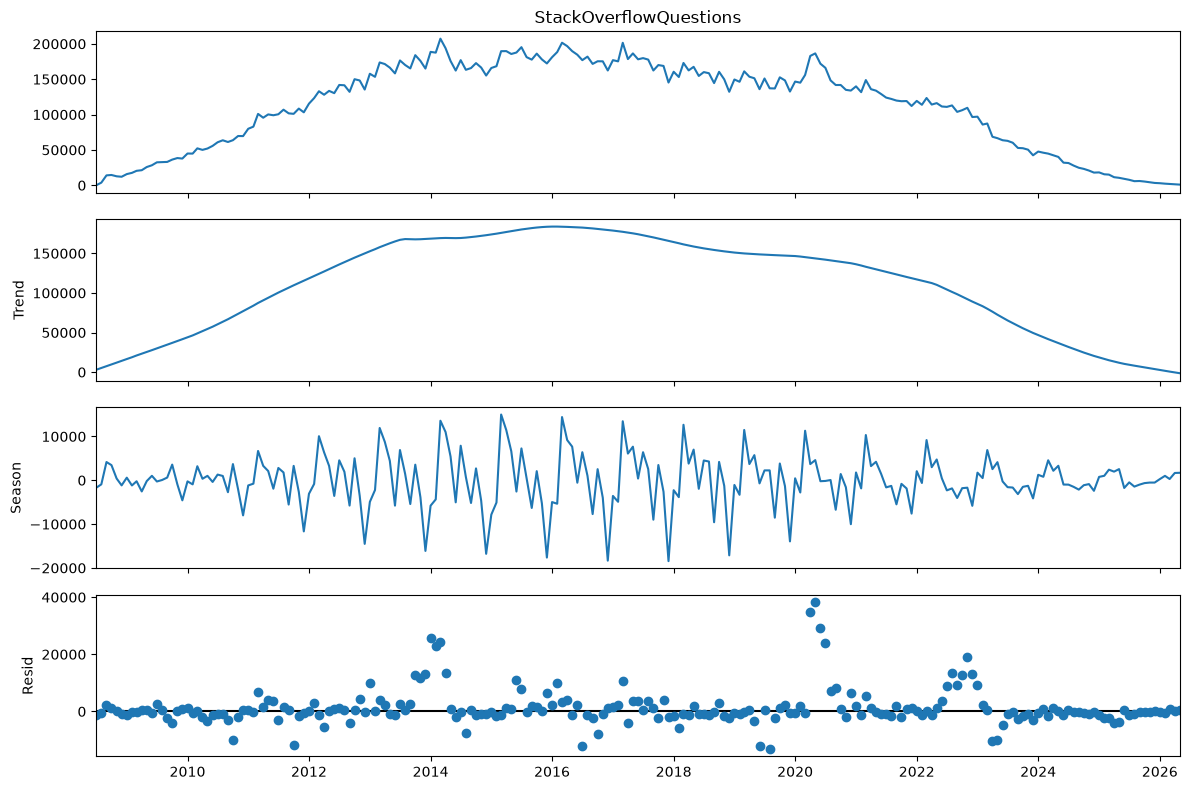

In [8]:
from statsmodels.tsa.seasonal import STL
series = monthly.dropna()
if len(series) >= 36:
    stl = STL(series, period=12, robust=True).fit()
    fig = stl.plot()
    fig.set_size_inches(12, 8)
    save_figure(fig, ANALYSIS_DIR / "questions_stl.png")
    plt.show()
else:
    print("Insufficient monthly observations for STL decomposition.")

## Takeaways
Interpret the figures descriptively. Structural changes are examined separately in `02_structural_breaks.ipynb`; this notebook does not attribute observed changes to any external event.